In [1]:
import xarray as xr 
from dask.distributed import Client, LocalCluster
import glob
import numpy as np
from tqdm.notebook import tqdm
import dask.bag as db

In [2]:

cluster = LocalCluster(n_workers=32, memory_limit='4GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 64,Total memory: 128.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35639,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39997,Total threads: 2
Dashboard: http://127.0.0.1:41905/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:43201,


In [3]:
main_path_data = '/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily'
files_u850 = sorted(glob.glob(f"{main_path_data}/u850/*"))
files_v850 = sorted(glob.glob(f"{main_path_data}/v850/*"))
files_slp = sorted(glob.glob(f"{main_path_data}/slp/*"))
all_files = [files_u850, files_v850, files_slp]

In [ ]:
def get_data(year):
    ds_year = xr.concat([xr.open_dataset(file,  engine='h5netcdf') for file in files_u850 if f'{year:.0f}' in file], dim='time')
    ds_year.to_netcdf(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/u850/yearly/u850_{year:.0f}_era5_1deg_daily_NH.nc')


years = np.arange(1940,2025,1)
for year in tqdm(years):
    get_data(year)


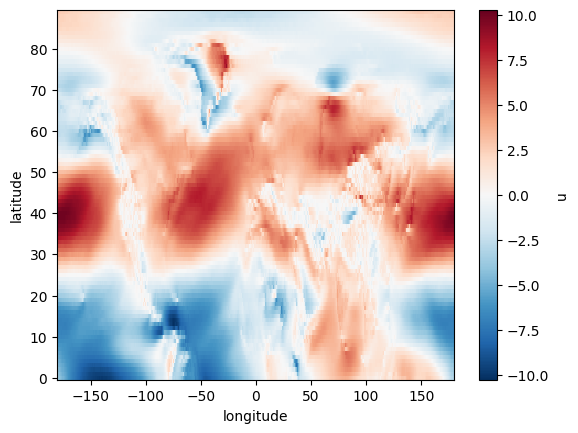

In [11]:
xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/u850/yearly/u850_1940_era5_1deg_daily_NH.nc').u.mean('time').plot()

In [12]:
def get_data(year):
    ds_year = xr.concat([xr.open_dataset(file,  engine='h5netcdf') for file in files_v850 if f'{year:.0f}' in file], dim='time')
    ds_year.to_netcdf(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/v850/yearly/v850_{year:.0f}_era5_1deg_daily_NH.nc')


years = np.arange(1940,2025,1)
for year in tqdm(years):
    get_data(year)

  0%|          | 0/85 [00:00<?, ?it/s]

In [4]:
def get_data(year):
    ds_year = xr.concat([xr.open_dataset(file,  engine='h5netcdf') for file in files_slp if f'{year:.0f}' in file], dim='time')
    ds_year.to_netcdf(f'/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/slp/yearly/slp_{year:.0f}_era5_1deg_daily_NH.nc')


years = np.arange(1940,2025,1)
for year in tqdm(years):
    if year not in [1943, 1966]:
        continue
    get_data(year)

  0%|          | 0/85 [00:00<?, ?it/s]

In [5]:
ds = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/slp/yearly/slp_1940_era5_1deg_daily_NH.nc')

In [ ]:
ds = xr.open_mfdataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/slp/yearly/*.nc', parallel=True)

In [6]:
ds_year = xr.concat([xr.open_dataset(file,  engine='h5netcdf') for file in files_slp if f'{year:.0f}' in file], dim='time')


ValueError: cannot reindex or align along dimension 'latitude' because the (pandas) index has duplicate values

In [ ]:
ds_u850 = xr.concat(results, dim='time').chunk(time=256)

ds_u850_mean = ds_u850.mean('time').compute()

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 46.30 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:

all_ds = []
for year in tqdm(years):
    all_ds.append(xr.concat([xr.open_dataset(file, chunks =dict(time=1)) for file in files_u850 if f'{year:.0f}' in file], dim='time'))

  0%|          | 0/86 [00:00<?, ?it/s]

OSError: [Errno -101] NetCDF: HDF error: '/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/u850/u850_2025_04_23_era5_1deg_daily.nc'

In [7]:
ds_u850 = xr.concat(all_ds, dim='time')

In [ ]:
ds_u850_mean = ds_u850.mean('time').load()

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 45.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [10]:
xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/ERA5_daily/u850/u850_1976_01_01_era5_1deg_daily.nc')

<xarray.Dataset> Size: 263kB
Dimensions:    (latitude: 90, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
    time       datetime64[ns] 8B ...
Data variables:
    u          (latitude, longitude) float64 259kB ...

In [ ]:
ds = xr.open_mfdataset(all_files, combine='nested', concat_dim=['var_name','time'], parallel=True)

/Data/gfi/users/rogui7909/virtual_envs/ml-env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 38.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
